In [1]:
import numpy as np
import pandas as pd

from skimage import io
from skimage.measure import regionprops_table
from scipy.ndimage import generate_binary_structure, grey_erosion

from MEDUSSA.utils import BorderRemoval
from MEDUSSA.transform import ConfIntSampler
from MEDUSSA.measure import SizeDataFrame
from cellpose_omni.metrics import average_precision

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene,f_oneway,kruskal,tukey_hsd

from glob import glob

footprint = generate_binary_structure(2, 1)
backgrounds = pd.read_csv('/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/backgrounds.csv').groupby(['Condition','Type']).mean().reset_index()

print(np.unique(backgrounds['Condition']))

raw_backgrounds = backgrounds[backgrounds['Type'] == 'Raw']
deconvolved_backgrounds = backgrounds[backgrounds['Type'] == 'Deconvolved']
restored_backgrounds = backgrounds[backgrounds['Type'] == 'Restored']

illuminations = ['0.010s\n10%','0.010s\n50%','0.025s\n10%','0.025s\n50%', #Noisy, i1, i2, i3
                 '0.050s\n10%','0.050s\n50%','0.100s\n10%','0.100s\n50%', #i4, i5, i6, i7
                 '0.100s\n100%','0.200s\n10%','0.200s\n50%','0.200s\n100%'] #i8, i9, i10, Target


['Noisy' 'Target' 'i1' 'i10' 'i2' 'i3' 'i4' 'i5' 'i6' 'i7' 'i8' 'i9']


In [2]:
def BenchMarkDF(target_path,gt_path,background_df,label='Target'):

    gt_names = sorted(glob(f'{gt_path}/*.tif'))

    bg = np.array(background_df[background_df['Condition']==label]['Mean'])[0]

    names = [gt.split('/')[-1].replace('.tif','') for gt in gt_names]    

    gt_masks = []
    target_masks = []
    imgs = []

    SNRs = []
    
    for i,n in enumerate(names):

        target = sorted(glob(f'{target_path}/{n}*'))

        if len(target) == 1:

            gtmasks = BorderRemoval(io.imread(gt_names[i]))
        
            target_masks.append(BorderRemoval(io.imread(target[0])))
            gt_masks.append(gtmasks)
            
            img = io.imread(target[0].replace('masks/','').replace('_cp_masks.png','.tif'))
    
            contours = gtmasks - grey_erosion(gtmasks,footprint=footprint)
    
            mean_signal = regionprops_table(label_image=contours,intensity_image=img,properties=['intensity_mean'])['intensity_mean'].mean()
    
            SNRs.append(mean_signal/bg)
            
    JI, tp, fp, fn = average_precision(gt_masks,target_masks,threshold=[0.8])
    f1 = 2*tp/(2*tp+fn+fp)
    
    df = pd.DataFrame()
    
    f1_ = [f[0] for f in f1]
    
    df.insert(0,'F1 score',f1_)
    df.insert(0,'Illumination',label)
    df.insert(2,'SNR',SNRs)
    
    return df

In [3]:
### RAW IMAGES

gt_path = '/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Benchmarking_masks/masks/'

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

raw_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Selected_planes_raw/{f}/masks/'
   
    df = BenchMarkDF(target_path=target_path,gt_path=gt_path,label=f,background_df=raw_backgrounds)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    raw_dfs.append(df)

full_df_raw = pd.concat(raw_dfs,ignore_index=True)


/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered 

In [4]:
### Deconvolved images

gt_path = '/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Benchmarking_masks/masks/'

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

deconvolved_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/For_benchmarking/{f}/masks/'
   
    df = BenchMarkDF(target_path=target_path,gt_path=gt_path,label=f,background_df=deconvolved_backgrounds)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    deconvolved_dfs.append(df)

full_df_deconvolved = pd.concat(deconvolved_dfs,ignore_index=True)


/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered 

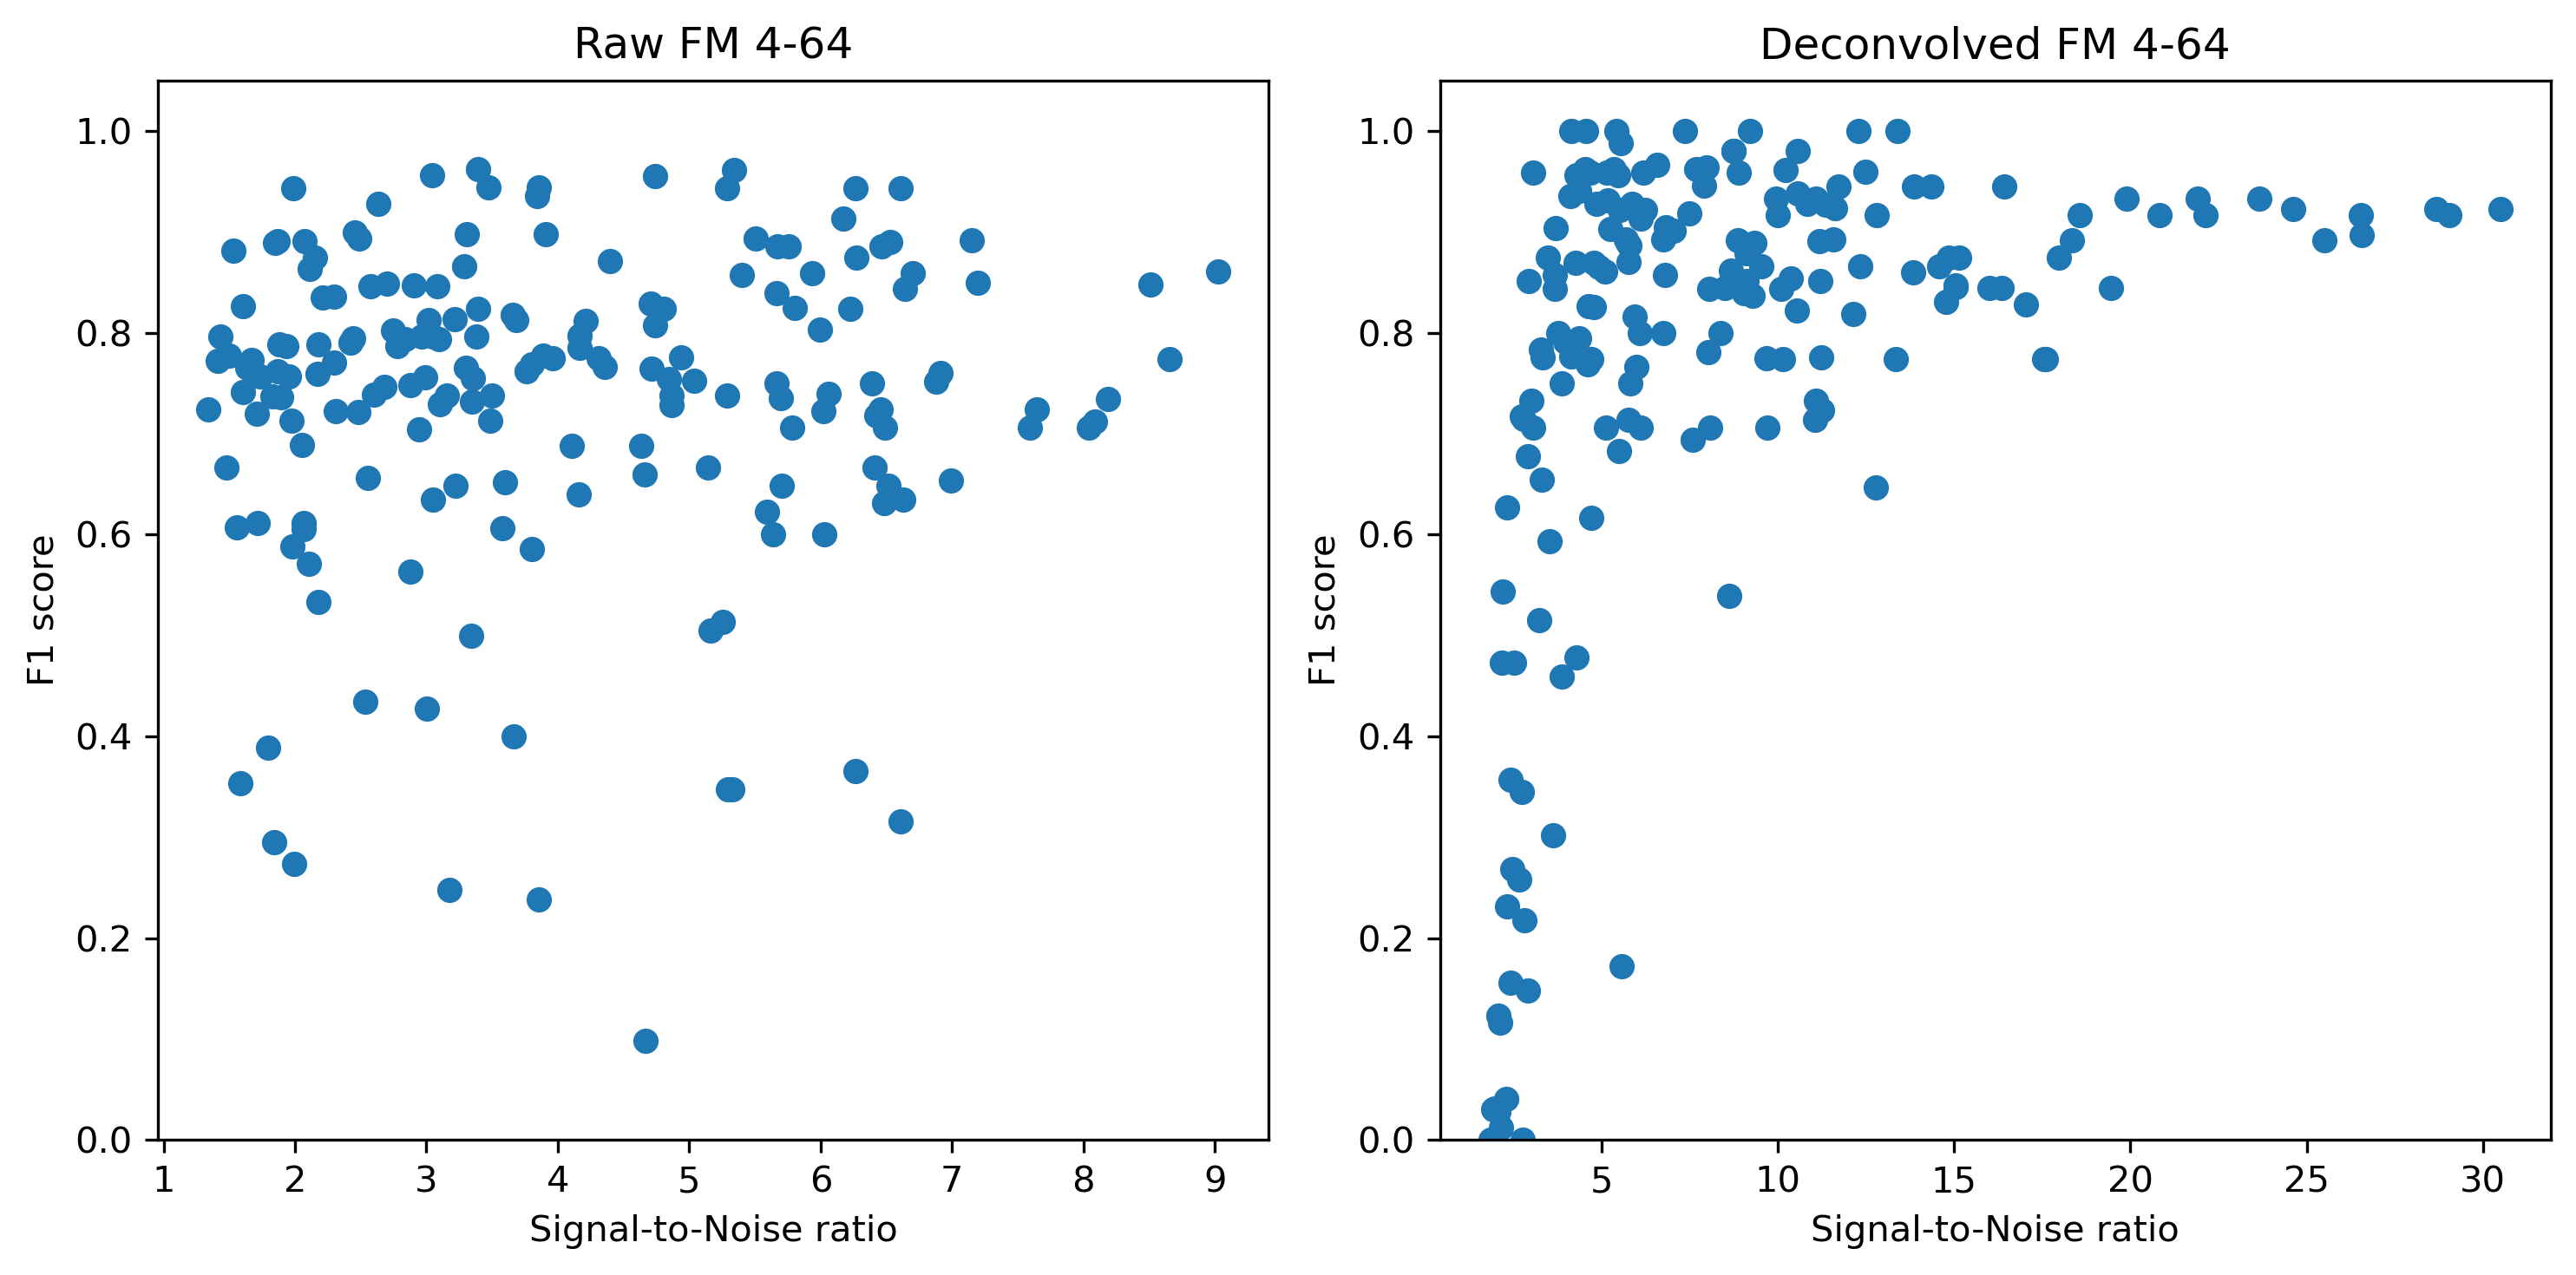

In [5]:
fig,ax = plt.subplots(dpi=300,figsize=(10,5),ncols=2)

ax[0].scatter(full_df_raw['SNR'],full_df_raw['F1 score'])
ax[0].set_xlabel('Signal-to-Noise ratio')
#ax[0].set_xlim(0,18)
ax[0].set_ylabel('F1 score')
ax[0].set_ylim(0,1.05)
ax[0].set_title('Raw FM 4-64')

ax[1].scatter(full_df_deconvolved['SNR'],full_df_deconvolved['F1 score'])
ax[1].set_xlabel('Signal-to-Noise ratio')
#ax[1].set_xlim(0,18)
ax[1].set_ylabel('F1 score')
ax[1].set_ylim(0,1.05)
ax[1].set_title('Deconvolved FM 4-64')

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_SNR_F1_evenX.png')

In [13]:
### RESTORED IMAGES

gt_path = '/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Benchmarking_masks/masks/'

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

restored_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/CARE_predictions/{f}/masks/'
   
    df = BenchMarkDF(target_path=target_path,gt_path=gt_path,label=f,background_df=restored_backgrounds)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    restored_dfs.append(df)

full_df_restored = pd.concat(restored_dfs,ignore_index=True)

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered 

In [7]:
print(len(full_df_raw[full_df_raw['F1 score']>=0.9]))
print(len(full_df_deconvolved[full_df_deconvolved['F1 score']>=0.9]))
print(len(full_df_restored[full_df_restored['F1 score']>=0.9]))

13
63
59


In [10]:
full_df_deconvolved.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS13_deconvolved_data.csv')
full_df_restored.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS13_restored_data.csv')

In [12]:
full_df_restored1 = pd.read_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS13_restored_data.csv')

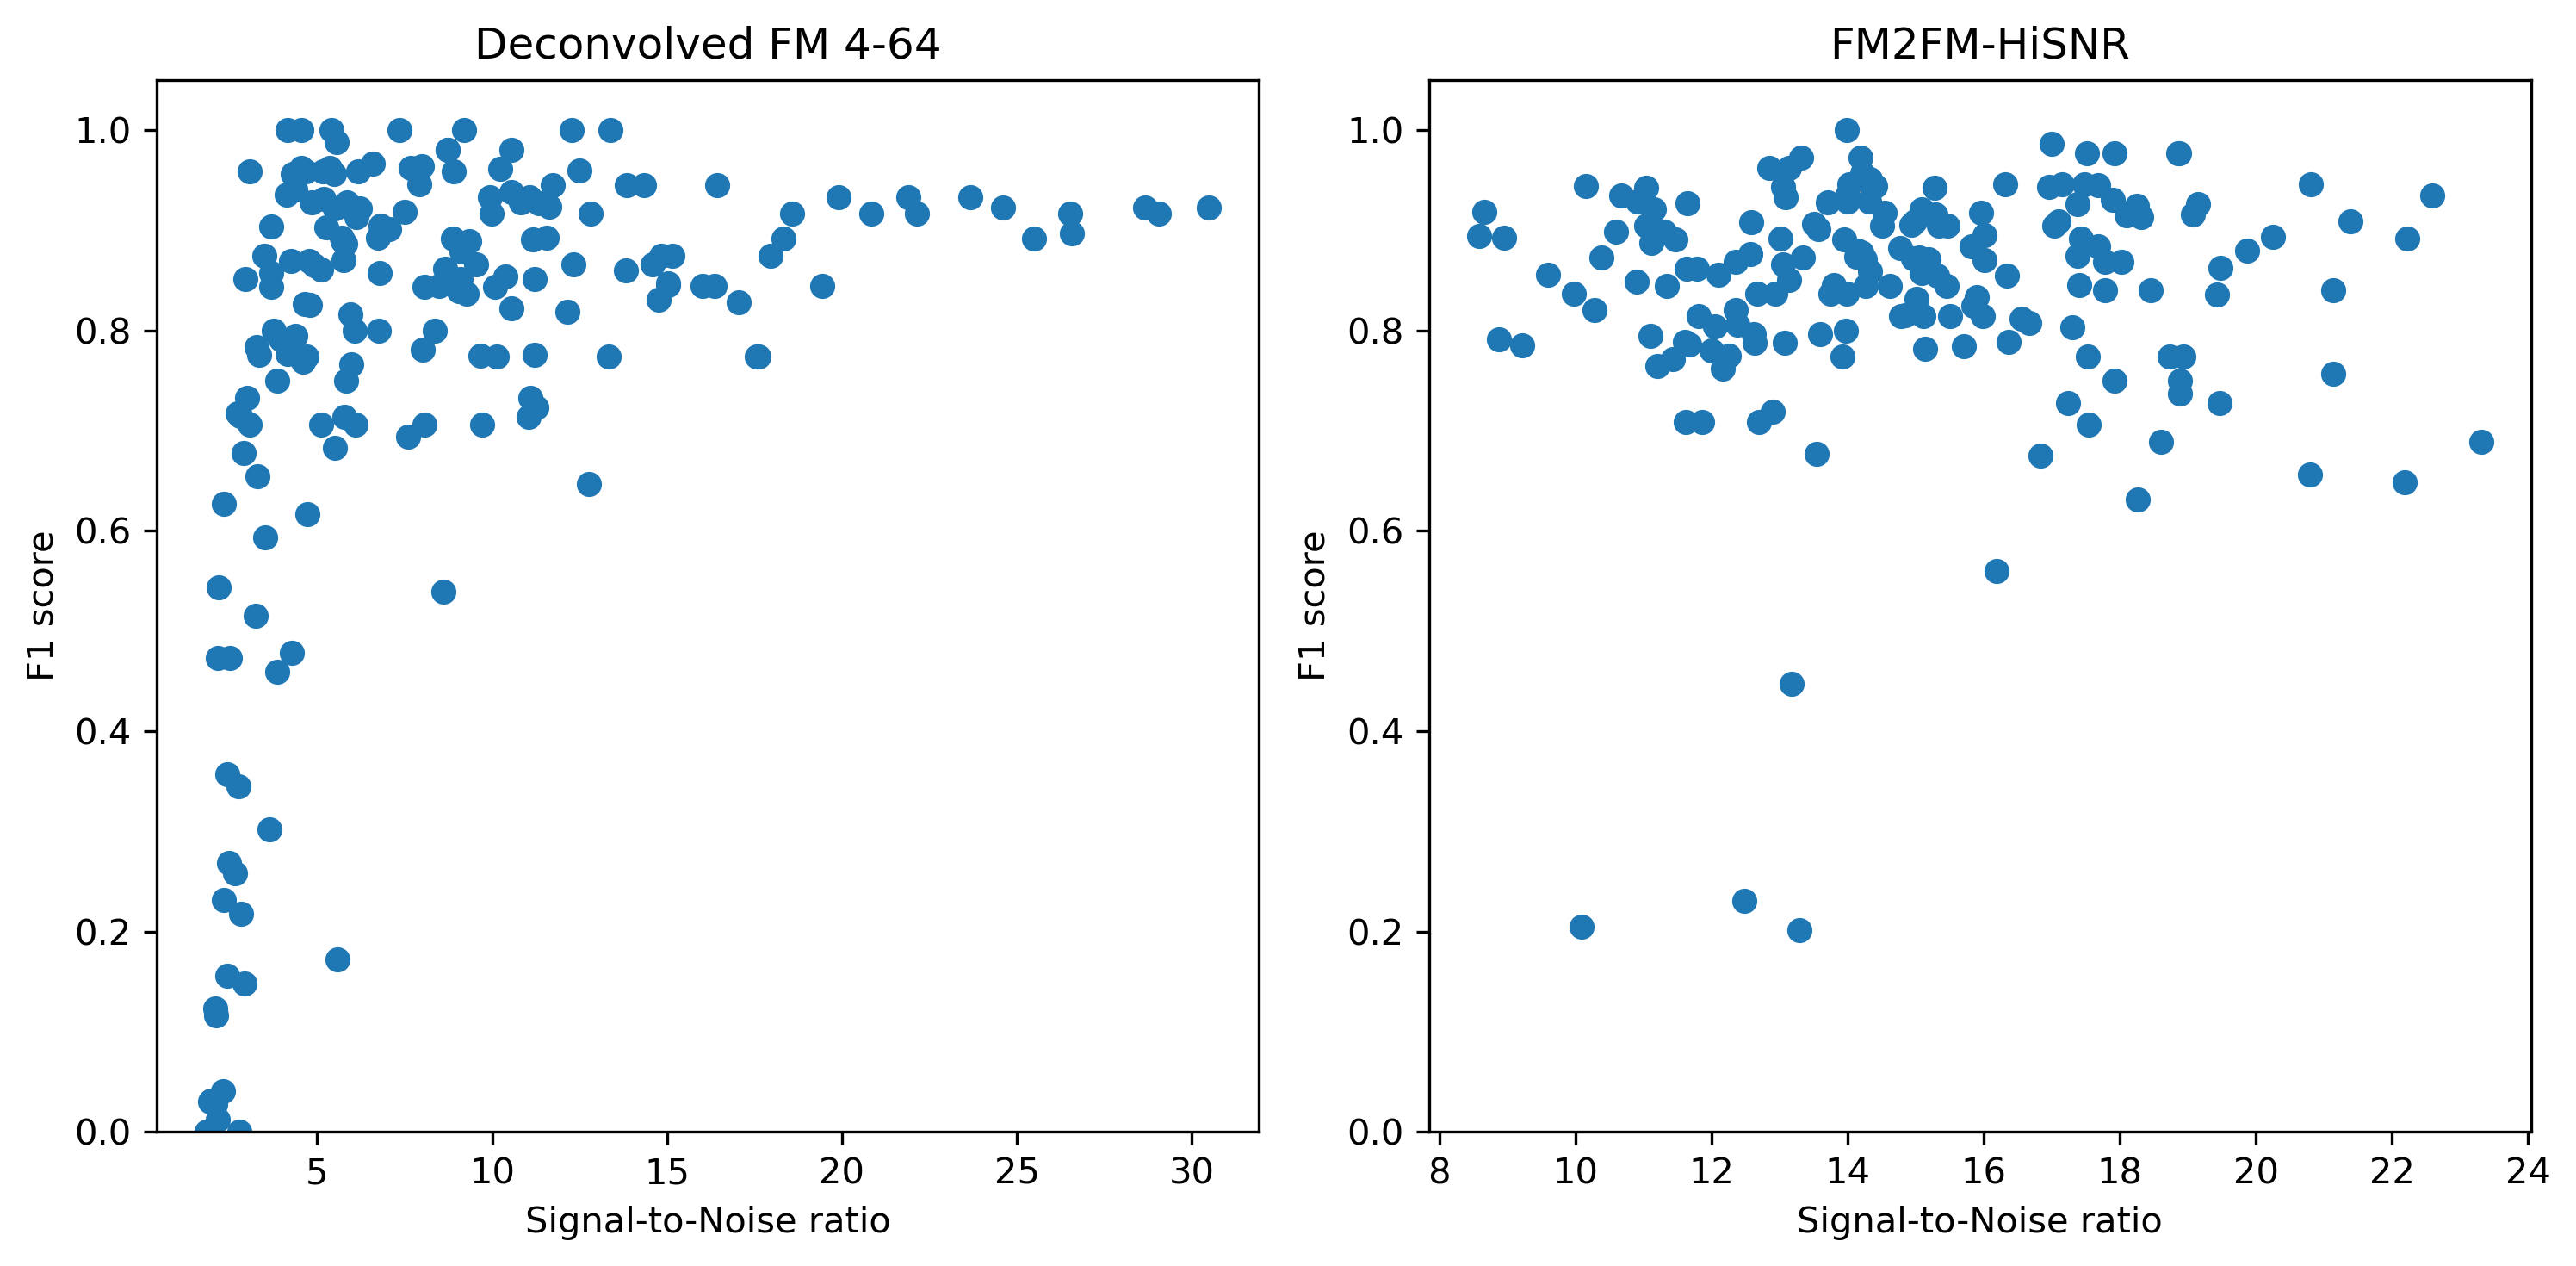

In [8]:
fig,ax = plt.subplots(dpi=300,figsize=(10,5),ncols=2)

ax[0].scatter(full_df_deconvolved['SNR'],full_df_deconvolved['F1 score'])
ax[0].set_xlabel('Signal-to-Noise ratio')
ax[0].set_ylabel('F1 score')
ax[0].set_ylim(0,1.05)
ax[0].set_title('Deconvolved FM 4-64')

ax[1].scatter(full_df_restored['SNR'],full_df_restored['F1 score'])
ax[1].set_xlabel('Signal-to-Noise ratio')
ax[1].set_ylabel('F1 score')
ax[1].set_ylim(0,1.05)
ax[1].set_title('FM2FM-HiSNR')

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS13/F1_vs_SNR.png')

(0.0, 1.0)

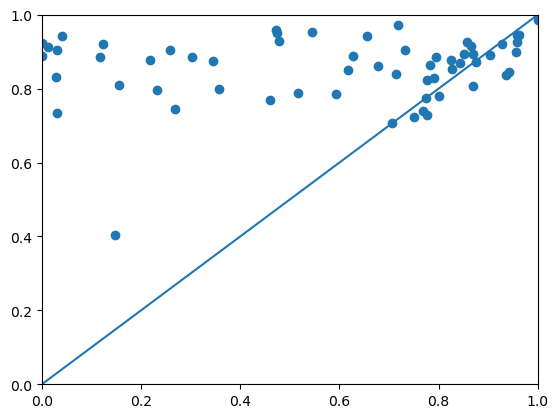

In [54]:
noisy_d = full_df_deconvolved[full_df_deconvolved['SNR'] <= 5]
noisy_r = full_df_restored[full_df_deconvolved['SNR'] <= 5]

plt.scatter(noisy_d['F1 score'],noisy_r['F1 score'])
plt.plot([0,1],[0,1])
plt.xlim(0,1)
plt.ylim(0,1)

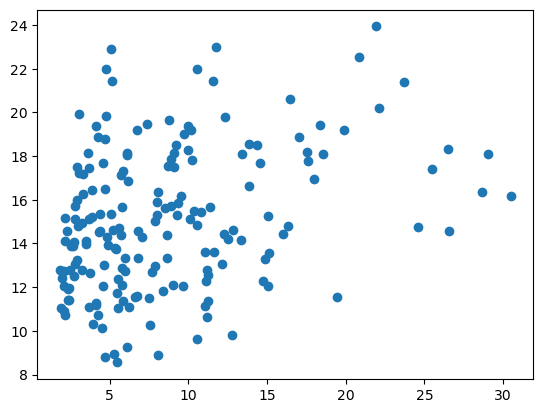

In [46]:
plt.scatter(full_df_deconvolved['SNR'],full_df_restored['SNR'])

In [75]:
full_df_raw.insert(0,'Type','Raw')
full_df_deconvolved.insert(0,'Type','Deconvolved')
full_df_restored.insert(0,'Type','Restored')

joint_df = pd.concat([full_df_raw,full_df_deconvolved,full_df_restored],ignore_index=True)

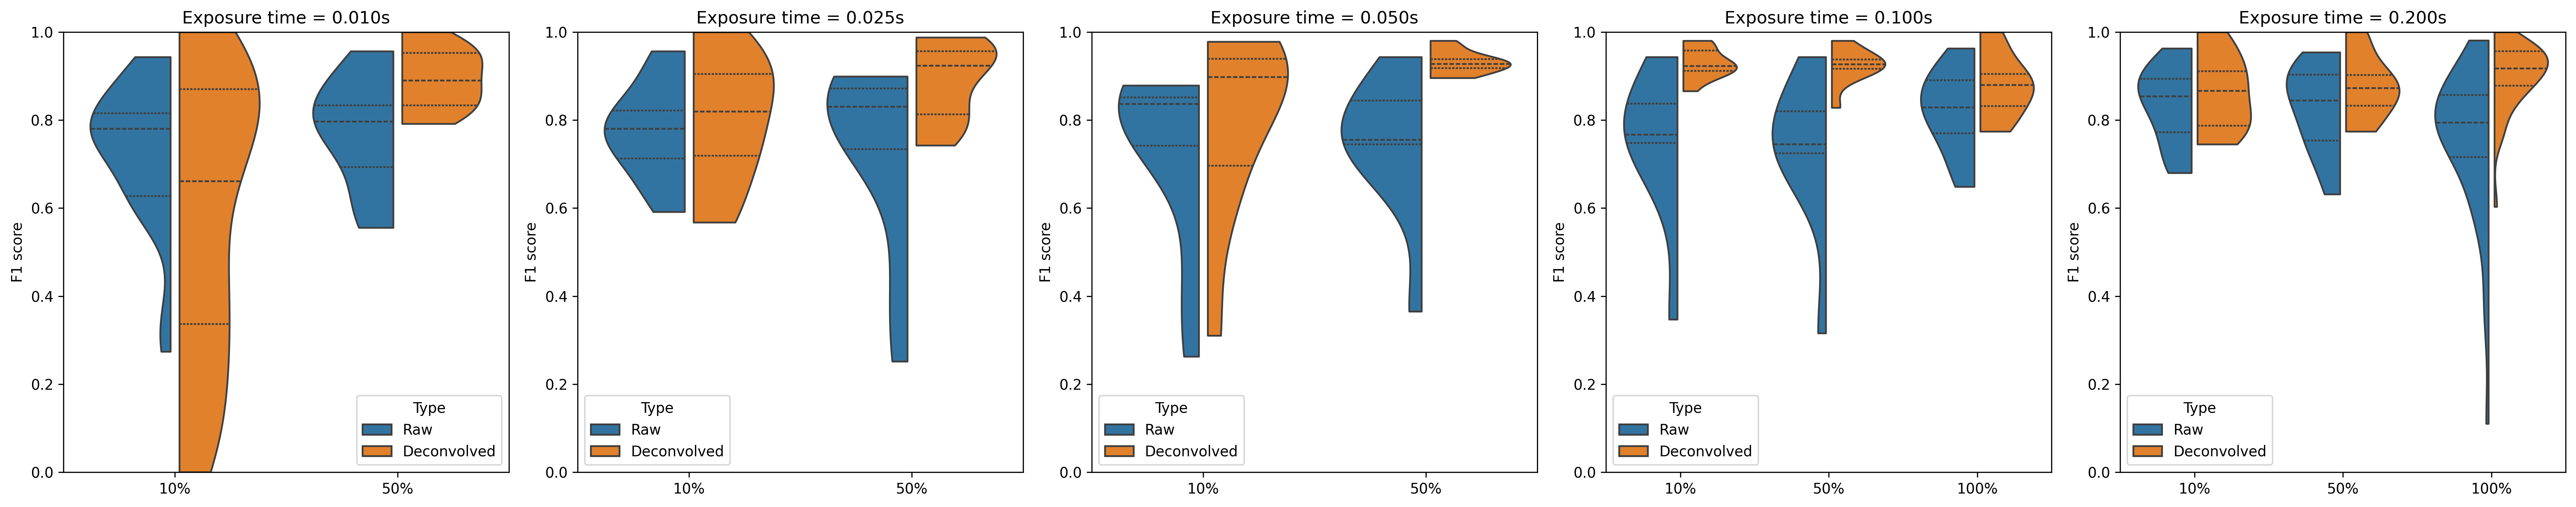

In [38]:
### Mini-plots by exposure time: effect of light transmission percentage

exposures = ['0.010s', '0.025s', '0.050s', '0.100s', '0.200s']

fig,ax = plt.subplots(dpi=300,ncols=len(exposures),figsize=(5*len(exposures),5))

for i,e in enumerate(exposures):

    subdf = joint_df[joint_df['Exposure time'] == e]

    sns.violinplot(data=subdf,x='Light transmission',y='F1 score',cut=0,inner='quart',density_norm='width',hue='Type',split=True,gap=0.1,ax=ax[i])
    ax[i].set_ylim(0,1)
    ax[i].set_xlabel('')
    ax[i].set_title(f'Exposure time = {e}')    

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_F1_by_exposure.png')


2026-02-13 15:39:59,397 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-13 15:39:59,408 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-13 15:39:59,504 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-13 15:39:59,508 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-13 15:39:59,579 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

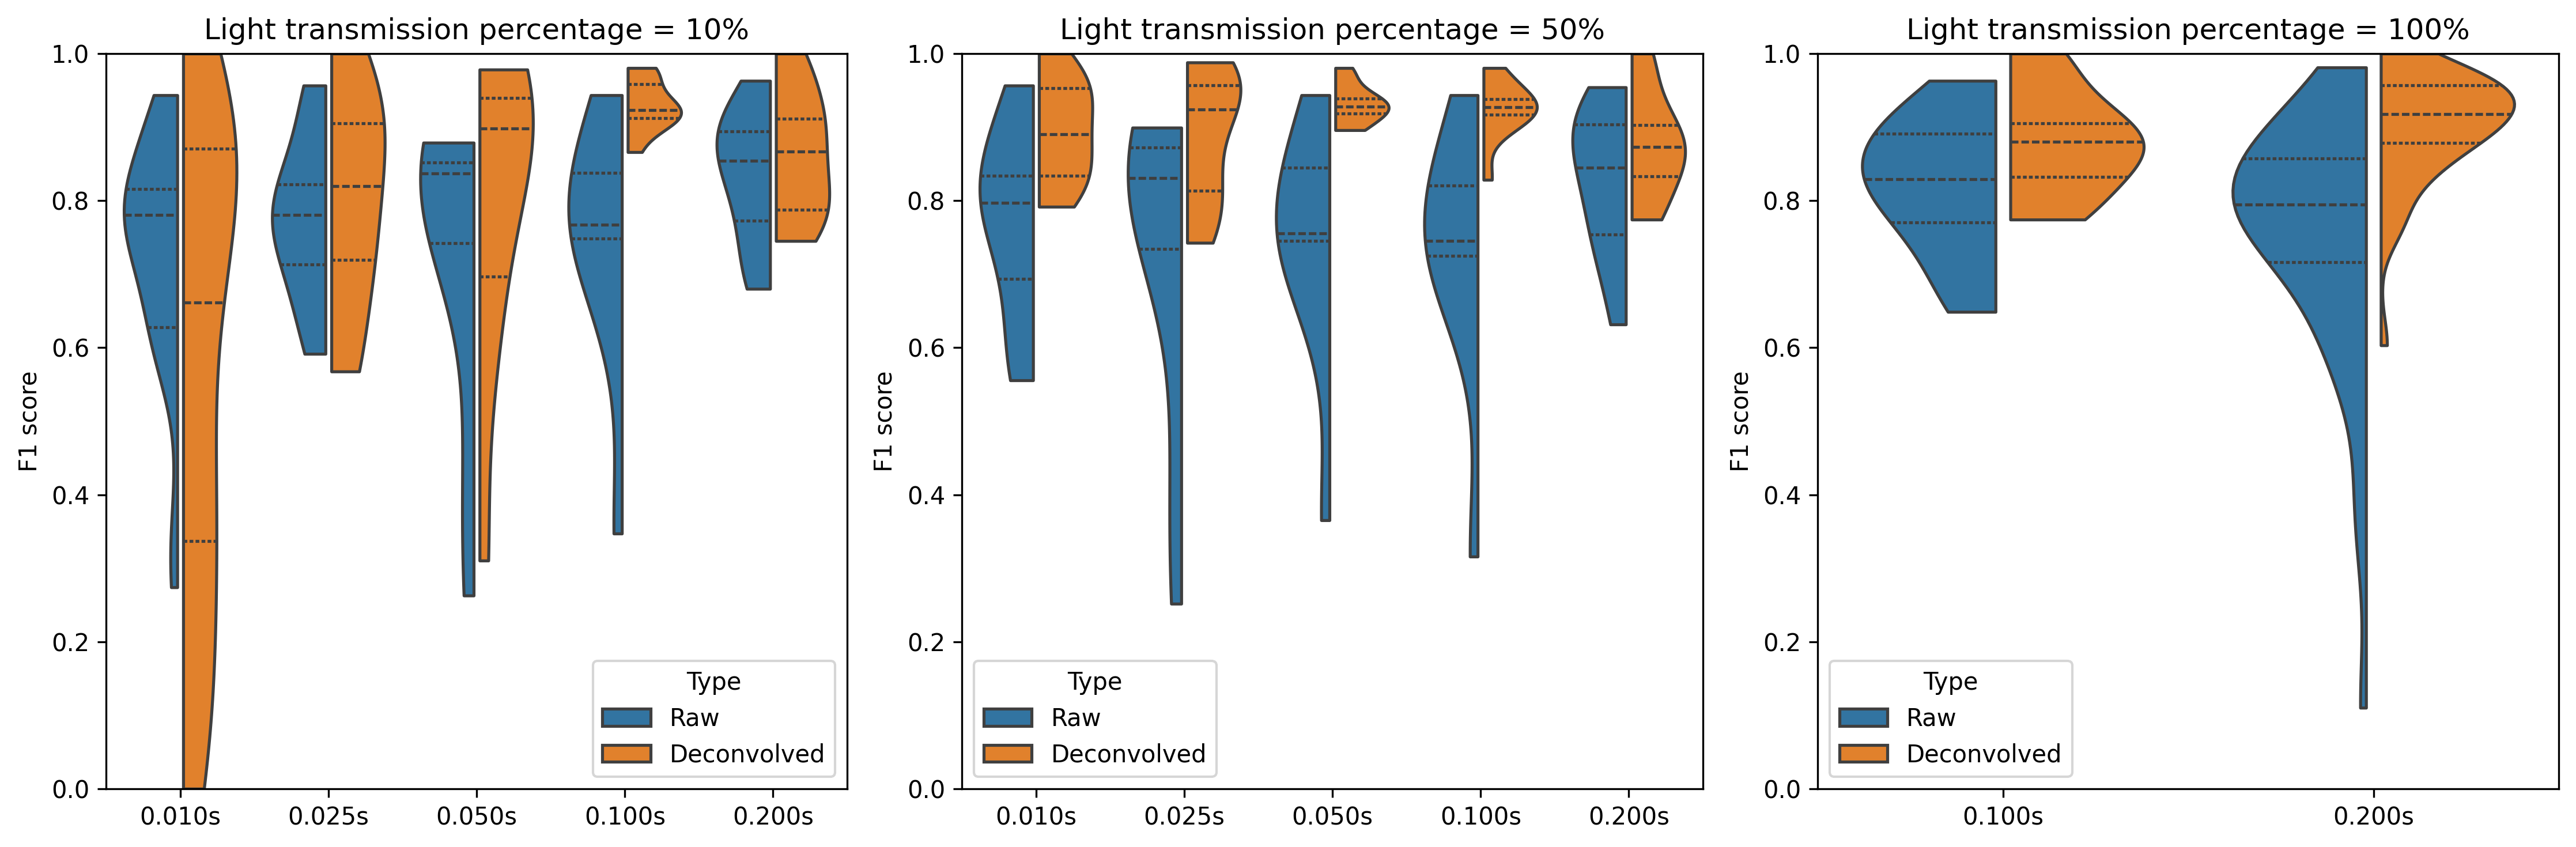

In [39]:
### Mini-plots by light transmission percentage: effect of exposure time

transmissions = ['10%', '50%', '100%']

fig,ax = plt.subplots(dpi=300,ncols=len(transmissions),figsize=(5*len(transmissions),5))

for i,t in enumerate(transmissions):

    subdf = joint_df[joint_df['Light transmission'] == t]

    sns.violinplot(data=subdf,x='Exposure time',y='F1 score',cut=0,inner='quart',density_norm='width',hue='Type',split=True,gap=0.1,ax=ax[i])
    ax[i].set_ylim(0,1)
    ax[i].set_xlabel('')
    ax[i].set_title(f'Light transmission percentage = {t}')    

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_F1_by_transmission.png')

### Measure the cells and compare

In [15]:
### RAW IMAGES

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

raw_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Selected_planes_raw/{f}/masks/'

    target_masks = sorted(glob(f'{target_path}*masks.png'))
    
    df = SizeDataFrame(target_masks,from_files=True,pixsize=33.02/512)

    df.drop('Image_full_path',axis=1,inplace=True)
    
    exposure,transmission = illuminations[i].split('\n')

    df.insert(0,'Imaging condition',f)
    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)

    df = df[df['Width']>0.3]
    
    raw_dfs.append(df)

full_df_raw = pd.concat(raw_dfs,ignore_index=True)
full_df_raw.insert(0,'Type','Raw')


/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge

In [16]:
### Deconvolved images

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

deconvolved_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/For_benchmarking/{f}/masks/'

    target_masks = sorted(glob(f'{target_path}*masks.png'))

    df = SizeDataFrame(target_masks,from_files=True,pixsize=33.02/512)
   
    df.drop('Image_full_path',axis=1,inplace=True)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(0,'Imaging condition',f) 
    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    df = df[df['Width']>0.3]

    deconvolved_dfs.append(df)

full_df_deconvolved = pd.concat(deconvolved_dfs,ignore_index=True)
full_df_deconvolved.insert(0,'Type','Deconvolved')

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge

In [34]:
L_sampled_raw = ConfIntSampler(df=full_df_raw,columns=['Imaging condition'],metric='Length')
L_sampled_deconvolved = ConfIntSampler(df=full_df_deconvolved,columns=['Imaging condition'],metric='Length')

w_sampled_raw = ConfIntSampler(df=full_df_raw,columns=['Imaging condition'],metric='Width')
w_sampled_deconvolved = ConfIntSampler(df=full_df_deconvolved,columns=['Imaging condition'],metric='Width')

joint_df_L = pd.concat([L_sampled_raw,L_sampled_deconvolved],ignore_index=True)
joint_df_w = pd.concat([w_sampled_raw,w_sampled_deconvolved],ignore_index=True)

In [68]:
Ls = []
ws = []

for f in folders:

    subdf = L_sampled_deconvolved[L_sampled_deconvolved['Imaging condition'] == f]
    L = np.array(subdf['Length'])
    Ls.append(L)

    subdf = w_sampled_deconvolved[w_sampled_deconvolved['Imaging condition'] == f]
    w = np.array(subdf['Width'])
    ws.append(w)
    
L_anova = kruskal(Ls[0],Ls[1],Ls[2],Ls[3],Ls[4],Ls[5],Ls[6],Ls[7],Ls[8],Ls[9],Ls[10],Ls[11])
w_anova = kruskal(ws[0],ws[1],ws[2],ws[3],ws[4],ws[5],ws[6],ws[7],ws[8],ws[9],ws[10],ws[11])

In [99]:
print(tukey_hsd(ws[0],ws[1],ws[2],ws[3],ws[4],ws[5],ws[6],ws[7],ws[8],ws[9],ws[10],ws[11]))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.079     0.000    -0.092    -0.067
 (0 - 2)     -0.048     0.000    -0.061    -0.034
 (0 - 3)     -0.066     0.000    -0.079    -0.053
 (0 - 4)     -0.054     0.000    -0.068    -0.040
 (0 - 5)     -0.077     0.000    -0.090    -0.063
 (0 - 6)     -0.075     0.000    -0.088    -0.062
 (0 - 7)     -0.077     0.000    -0.090    -0.064
 (0 - 8)     -0.072     0.000    -0.084    -0.061
 (0 - 9)     -0.069     0.000    -0.081    -0.057
 (0 - 10)     -0.073     0.000    -0.085    -0.061
 (0 - 11)     -0.081     0.000    -0.090    -0.073
 (1 - 0)      0.079     0.000     0.067     0.092
 (1 - 2)      0.032     0.000     0.016     0.048
 (1 - 3)      0.013     0.201    -0.003     0.029
 (1 - 4)      0.025     0.000     0.009     0.042
 (1 - 5)      0.003     1.000    -0.013     0.019
 (1 - 6)      0.004     1.000    -0.012     0.020
 (1 - 7)      0.002     1.000 

/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_60984/2868696276.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(illuminations)


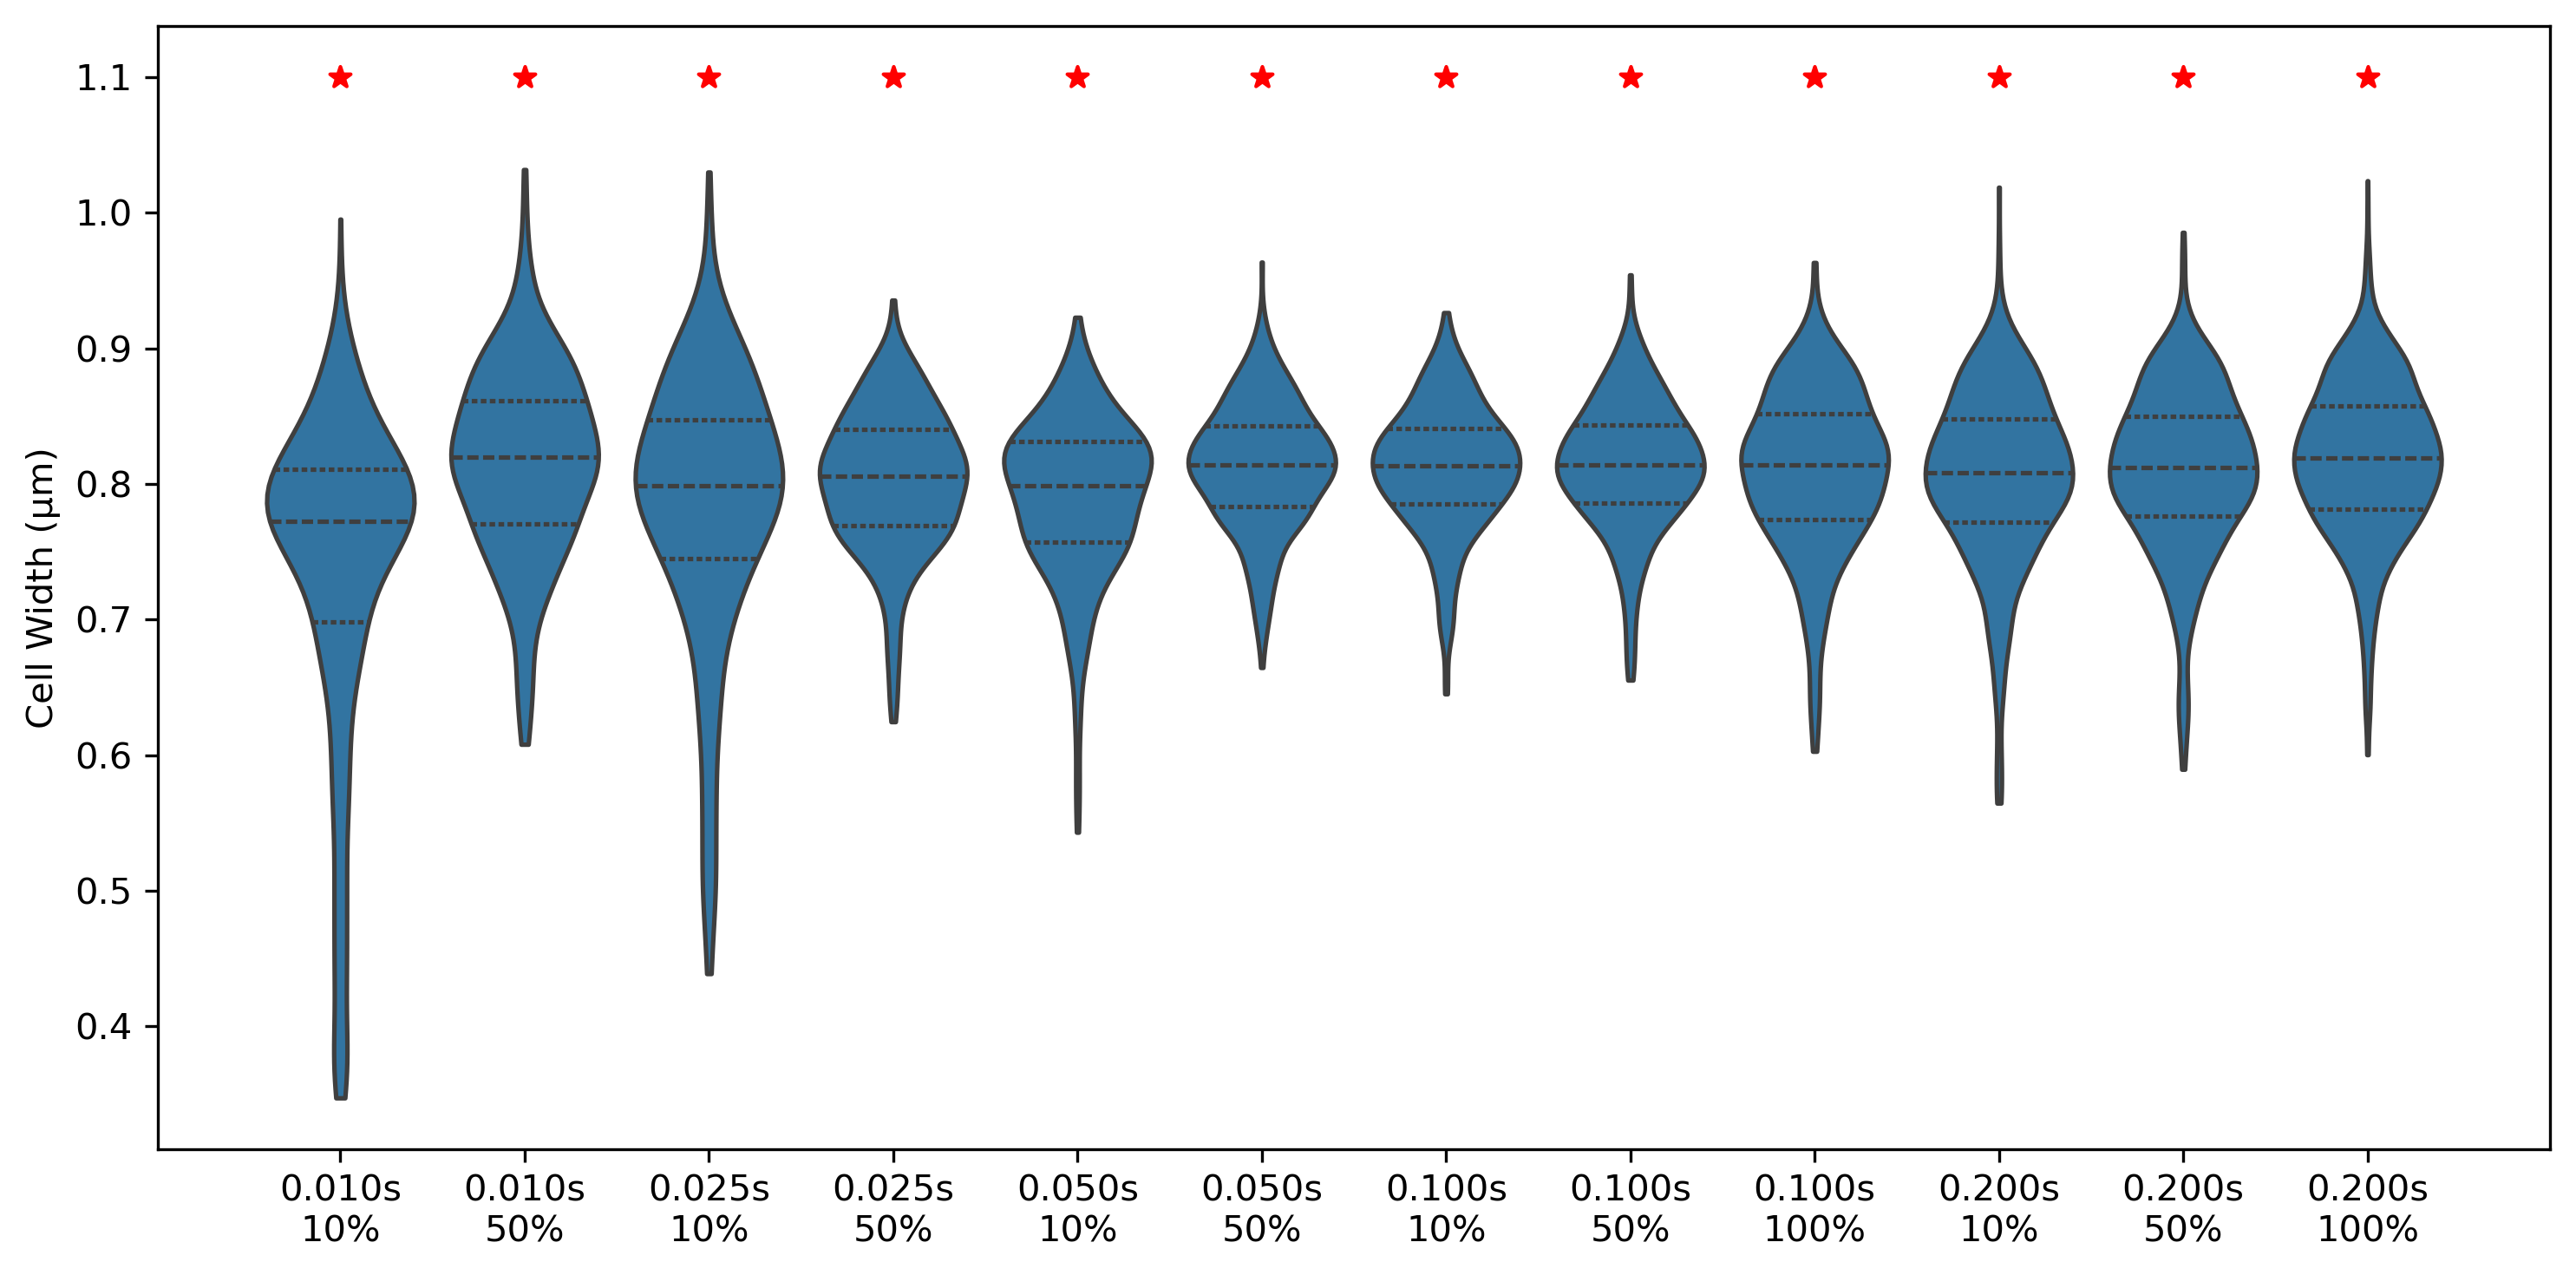

In [97]:
fig,ax = plt.subplots(dpi=300,figsize=(10,5))

sns.violinplot(data=w_sampled_deconvolved,x='Imaging condition',y='Width',order=folders,cut=0,inner='quart',density_norm='width',ax=ax)
ax.set_ylabel('Cell Width (µm)')
ax.set_xlabel('')
ax.set_xticklabels(illuminations)
ax.scatter(np.arange(0,12,1), np.repeat(1.1,12), marker="*", color="r")

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_Width_illuminations_deconvolved.png')

/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_60984/594418628.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(illuminations)


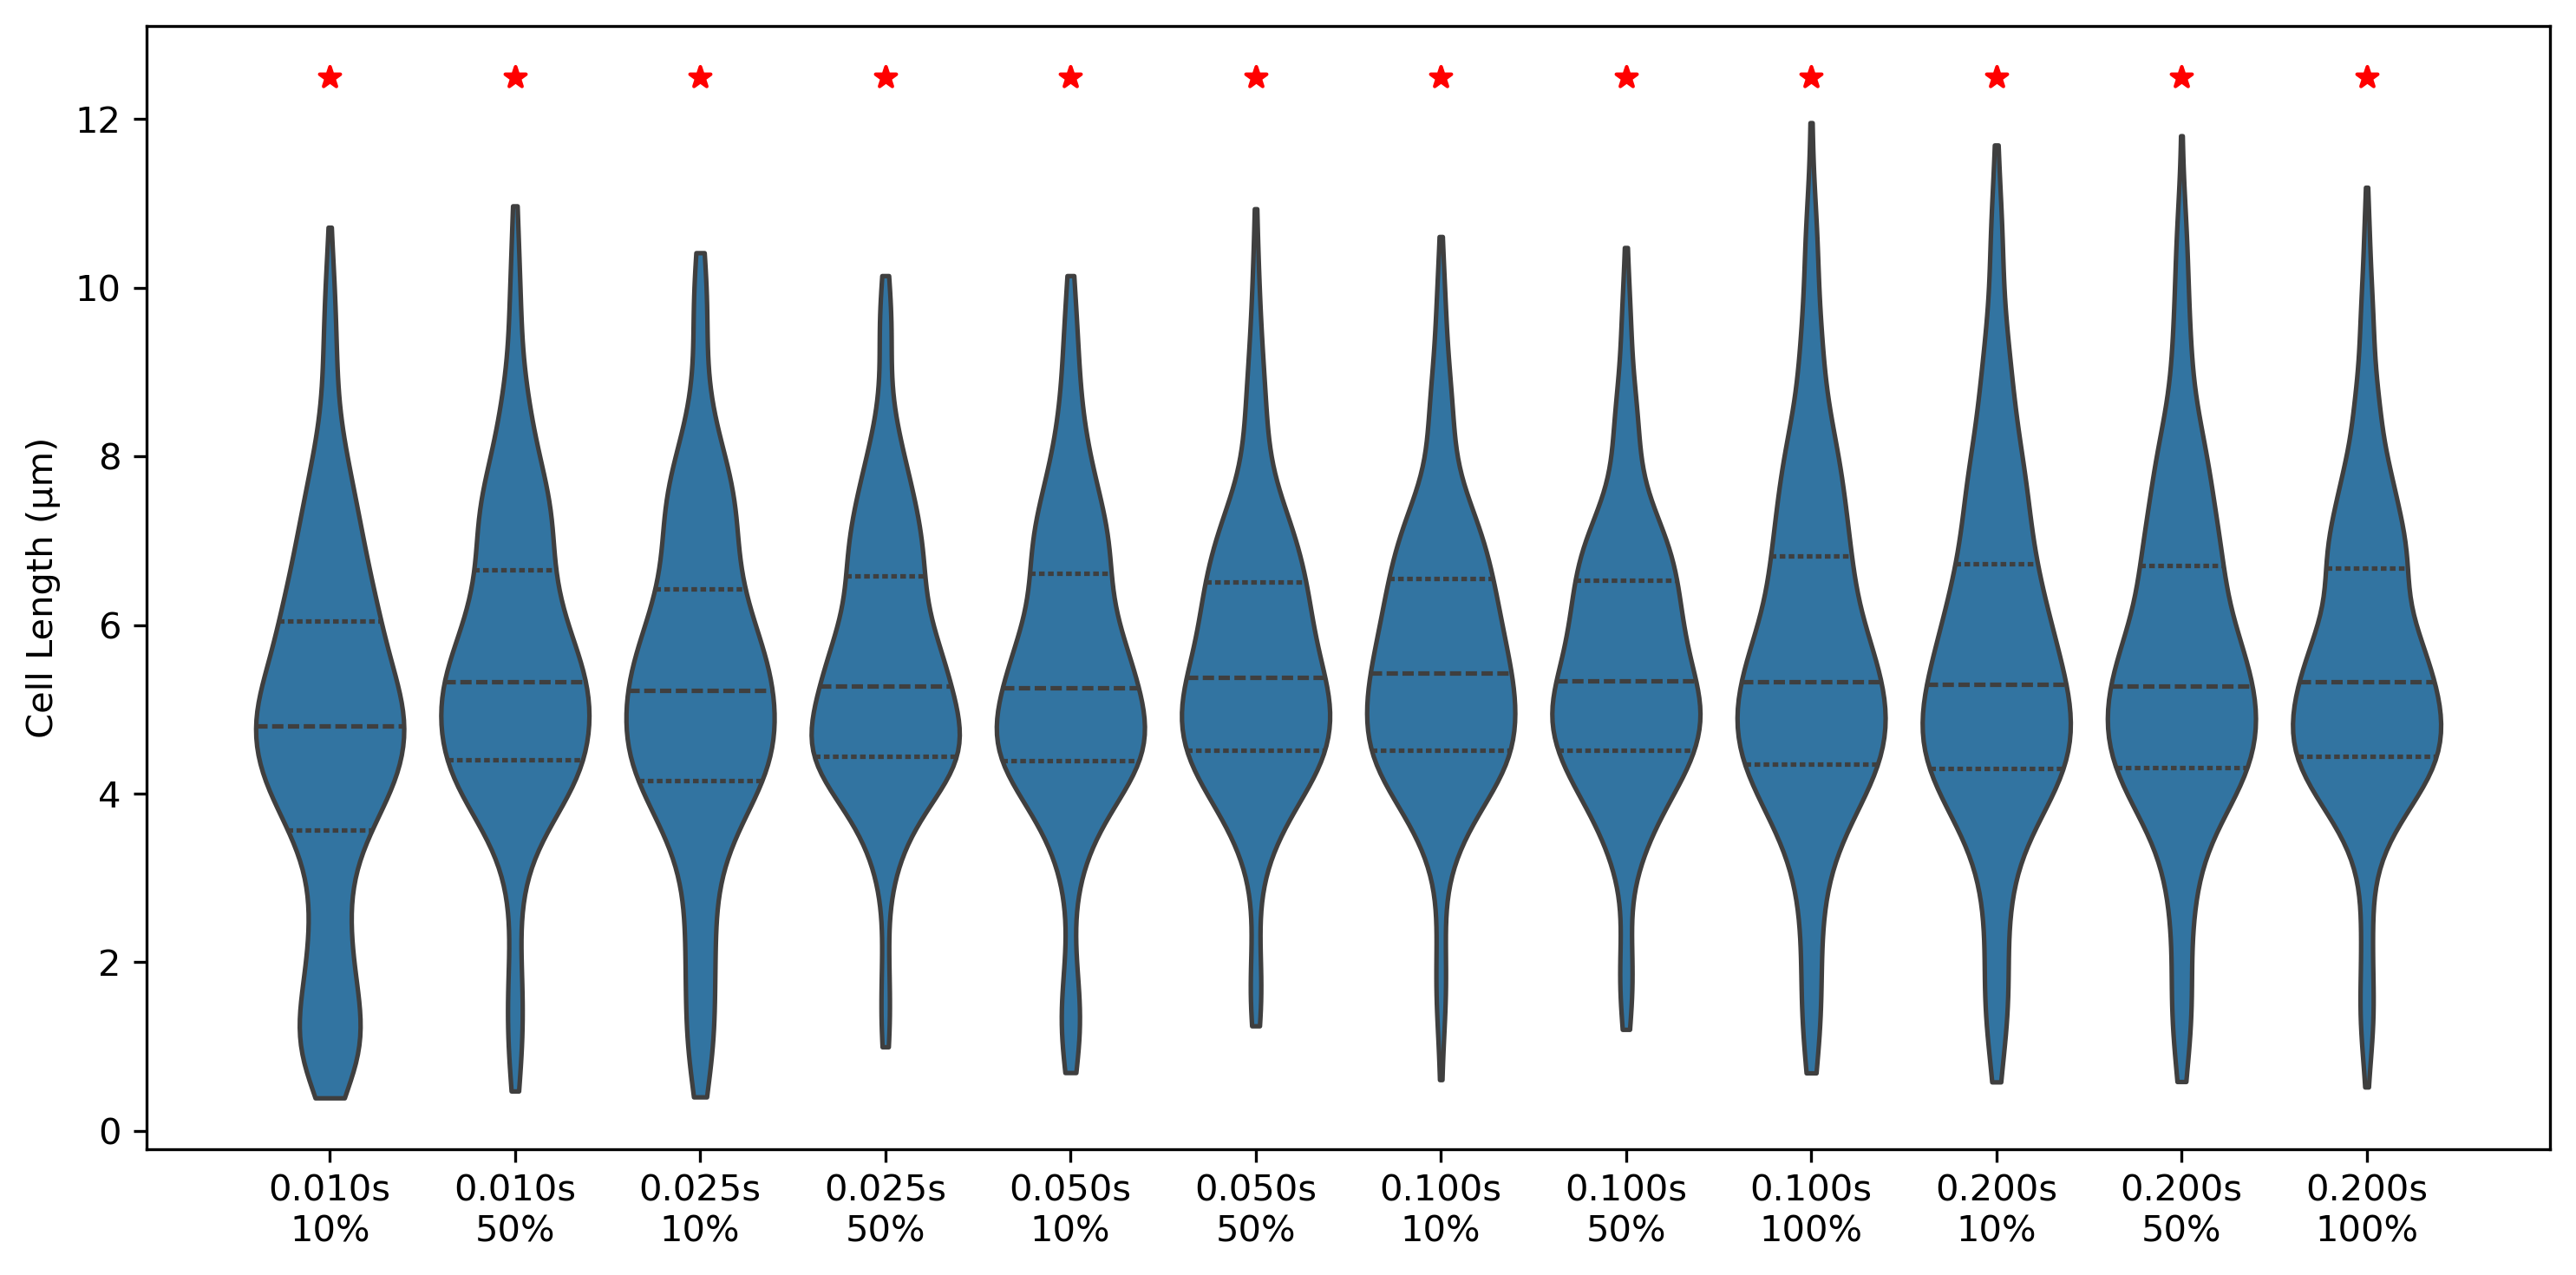

In [98]:
fig,ax = plt.subplots(dpi=300,figsize=(10,5))

sns.violinplot(data=L_sampled_deconvolved,x='Imaging condition',y='Length',order=folders,cut=0,inner='quart',density_norm='width',ax=ax)
ax.set_ylabel('Cell Length (µm)')
ax.set_xlabel('')
ax.set_xticklabels(illuminations)
ax.scatter(np.arange(0,12,1), np.repeat(12.5,12), marker="*", color="r")

fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig_Length_illuminations_deconvolved.png')

In [61]:
print(tukey_hsd(Ls[0],Ls[1],Ls[2],Ls[3],Ls[4],Ls[5],Ls[6],Ls[7],Ls[8],Ls[9],Ls[10],Ls[11]))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.816     0.000    -1.119    -0.512
 (0 - 2)     -0.508     0.000    -0.821    -0.196
 (0 - 3)     -0.787     0.000    -1.097    -0.478
 (0 - 4)     -0.709     0.000    -1.037    -0.382
 (0 - 5)     -0.846     0.000    -1.162    -0.531
 (0 - 6)     -0.860     0.000    -1.176    -0.545
 (0 - 7)     -0.792     0.000    -1.107    -0.477
 (0 - 8)     -0.862     0.000    -1.141    -0.584
 (0 - 9)     -0.821     0.000    -1.100    -0.541
 (0 - 10)     -0.786     0.000    -1.065    -0.507
 (0 - 11)     -0.834     0.000    -1.029    -0.639
 (1 - 0)      0.816     0.000     0.512     1.119
 (1 - 2)      0.307     0.270    -0.077     0.692
 (1 - 3)      0.028     1.000    -0.353     0.410
 (1 - 4)      0.106     0.999    -0.290     0.502
 (1 - 5)     -0.031     1.000    -0.417     0.356
 (1 - 6)     -0.045     1.000    -0.431     0.342
 (1 - 7)      0.024     1.000 

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
